**Geração de pontos 2D usando umadistribuição Gaussiana multivariada**

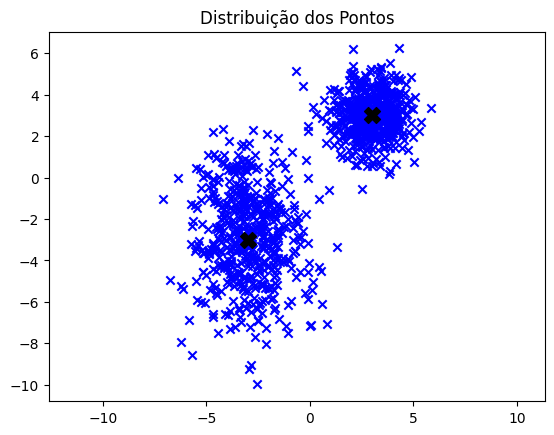

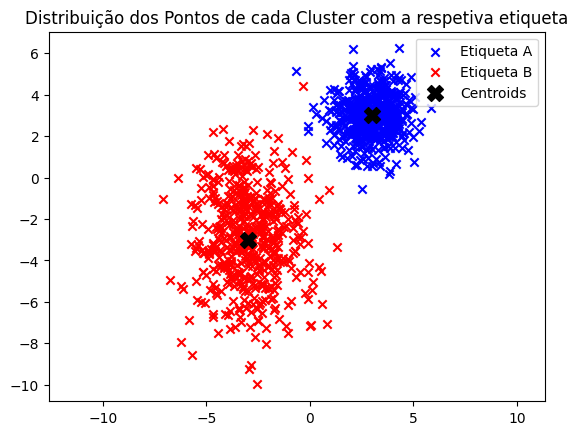

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import random

centroids = np.array([[3,3], [-3,-3]])
mean = [3, 3]
cov = [[1 , 0], [0, 1]]
a = np.random.multivariate_normal(mean, cov, 500).T
mean = [-3, -3]
cov = [[2 , 0], [0, 5]]
b = np.random.multivariate_normal(mean, cov, 500).T
c = np.concatenate((a, b) , axis = 1)
c = c.T
etiqueta_a = np.ones((a.shape[1], 1))
etiqueta_b = np.full((b.shape[1], 1), 2)
etiquetas = np.vstack((etiqueta_a, etiqueta_b))
c = np.hstack((c, etiquetas))
np.random. shuffle(c)
c = c.T
x = c[0]
y = c[1]
etiquetas = c[2]


plt.scatter(x, y, c='blue', marker='x')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.axis ( 'equal' )
plt.title('Distribuição dos Pontos')
plt.show()


plt.scatter(x[etiquetas == 1], y[etiquetas == 1], c='blue', marker='x', label='Etiqueta A')
plt.scatter(x[etiquetas == 2], y[etiquetas == 2], c='red', marker='x', label='Etiqueta B')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.axis('equal')
plt.legend()
plt.title('Distribuição dos Pontos de cada Cluster com a respetiva etiqueta')
plt.show()

np.savetxt('conjunto_de_etiquetas.txt', c.T, fmt='%.3f', delimiter=',', header='x,y,etiqueta', comments='')

**Implementação do algoritmo K-Means (1.2)**

Época 0 - r1: [-3.181;-0.584], r2: [1.424;4.183]
Época 1 - r1: [-3.106917455742391;-1.479565238779448], r2: [2.0311152131196213;3.7148948065544927]
Época 2 - r1: [-3.063936203590908;-2.0266552225315664], r2: [2.395650011572504;3.429602624062241]
Época 3 - r1: [-3.0423397853055425;-2.364592448325853], r2: [2.6110482482947743;3.2527750211614546]
Época 4 - r1: [-3.0291784970127558;-2.570538137781123], r2: [2.741009443849918;3.1460855373948506]
Época 5 - r1: [-3.0211577452734146;-2.6960455508976127], r2: [2.819421935090037;3.081714105787693]
Época 6 - r1: [-3.016269739097044;-2.772532273143944], r2: [2.8667323553752446;3.042875402469762]
Época 7 - r1: [-3.013290890585496;-2.8191448080908392], r2: [2.8952772444887542;3.0194419501174115]
Época 8 - r1: [-3.0114755208550634;-2.847551417112184], r2: [2.9124998920490652;3.0053033038126045]
Época 9 - r1: [-3.01036919831285;-2.864862971547291], r2: [2.9228912299802534;2.996772707623588]
Época 10 - r1: [-3.009694983277257;-2.875412978298691], r2: [

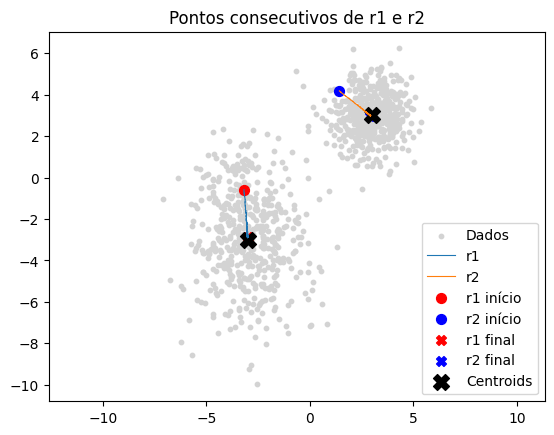

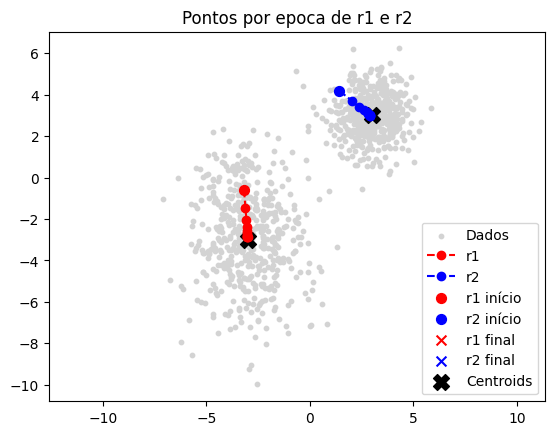

In [51]:
pontos = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
coordenadas= pontos[:, 0:2]
etiquetas = pontos[:,2]

r1 = coordenadas[random.randint(0 , len(coordenadas)-1)]
r2 = coordenadas[random.randint(0 , len(coordenadas)-1)]

alpha = 0.001
num_epocas = 10

r1_update = []
r2_update = []
r1_final = []
r2_final = []

r1_final.append(r1.copy())
r2_final.append(r2.copy())
print(f"Época 0 - r1: [{r1[0]};{r1[1]}], r2: [{r2[0]};{r2[1]}]")


for epoca in range(1, num_epocas + 1):
    for x in coordenadas:
        d1 = np.sqrt(np.sum((x-r1) ** 2))
        d2 = np.sqrt(np.sum((x-r2) ** 2))

        if d1 < d2:
            r1 = (1-alpha) * r1 + alpha * x
            r1_update.append(r1.copy())
        else:
            r2 = (1-alpha) * r2 + alpha * x
            r2_update.append(r2.copy())
    r1_final.append(r1.copy())
    r2_final.append(r2.copy())
    print(f"Época {epoca} - r1: [{r1[0]};{r1[1]}], r2: [{r2[0]};{r2[1]}]")

r1_update = np.array(r1_update)
r2_update = np.array(r2_update)
r1_final = np.array(r1_final)
r2_final = np.array(r2_final)

plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='o', s=10, label='Dados')
plt.plot(r1_update[:,0], r1_update[:,1], linewidth= 0.8, label='r1')
plt.plot(r2_update[:,0], r2_update[:,1], linewidth= 0.8, label='r2')
plt.scatter(r1_update[0,0], r1_update[0,1], c='red', marker='o', s=50, label='r1 início')
plt.scatter(r2_update[0,0], r2_update[0,1], c='blue', marker='o', s=50, label='r2 início')
plt.scatter(r1_update[-1,0], r1_update[-1,1], c='red', marker='X', s=50, label='r1 final')
plt.scatter(r2_update[-1,0], r2_update[-1,1], c='blue', marker='X', s=50, label='r2 final')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.title("Pontos consecutivos de r1 e r2")
plt.legend()
plt.axis('equal')
plt.show()

plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='o', s=10, label='Dados')
plt.plot(r1_final[:,0], r1_final[:,1], 'ro--', label='r1')
plt.plot(r2_final[:,0], r2_final[:,1], 'bo--', label='r2')
plt.scatter(r1_final[0,0], r1_final[0,1], c='red', marker='o', s=50, label='r1 início')
plt.scatter(r2_final[0,0], r2_final[0,1], c='blue', marker='o', s=50, label='r2 início')
plt.scatter(r1_final[-1,0], r1_final[-1,1], c='red', marker='x', s=50, label='r1 final')
plt.scatter(r2_final[-1,0], r2_final[-1,1], c='blue', marker='x', s=50, label='r2 final')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.title("Pontos por epoca de r1 e r2")
plt.legend()
plt.axis('equal')
plt.show()
    


Alínea 3

Com a variação do valor do alpha e das épocas foi possível concluir que em termos do alpha, quanto mais pequeno (10e-5), mais demorada será a sua convergência para o ponto médio do conjunto, no entanto, quando o alpha tem valores mais elevados, mais rápida será a sua convergência, e se o valor for 0,1 ou superior, o centroid vai oscilar em torno do ponto médio do conjunto.
Por outro lado, o valor das épocas afeta o tamanho da trajetoria do centroid, ou seja, quanto maior o número de épocas mais a trajetoria estende-se, estabilizando no ponto médio do conjunto.

**30 Repetições do primeiro tipo de kmeans**

Repetição 01 - r1 final: [2.945, 2.987], r2 final: [-2.981, -2.848]
Repetição 02 - r1 final: [-3.014, -2.891], r2 final: [2.940, 2.970]
Repetição 03 - r1 final: [-2.970, -2.848], r2 final: [2.937, 2.989]
Repetição 04 - r1 final: [-2.998, -2.889], r2 final: [2.951, 2.985]
Repetição 05 - r1 final: [2.876, 2.938], r2 final: [-3.020, -2.969]
Repetição 06 - r1 final: [-2.994, -2.902], r2 final: [2.906, 2.996]
Repetição 07 - r1 final: [2.920, 2.984], r2 final: [-2.989, -2.928]
Repetição 08 - r1 final: [-3.019, -2.921], r2 final: [2.884, 2.959]
Repetição 09 - r1 final: [-2.992, -2.886], r2 final: [2.944, 2.989]
Repetição 10 - r1 final: [2.950, 2.992], r2 final: [-2.990, -2.891]
Repetição 11 - r1 final: [-3.001, -2.902], r2 final: [2.932, 2.980]
Repetição 12 - r1 final: [2.921, 2.984], r2 final: [-3.006, -2.950]
Repetição 13 - r1 final: [-2.957, -2.857], r2 final: [2.952, 2.988]
Repetição 14 - r1 final: [-3.006, -2.906], r2 final: [2.908, 2.976]
Repetição 15 - r1 final: [-3.007, -2.909], r2 fi

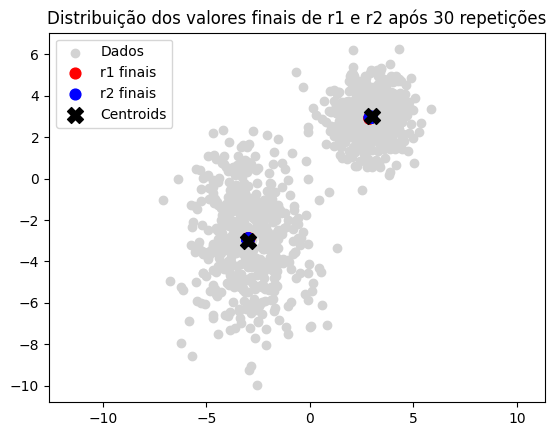

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


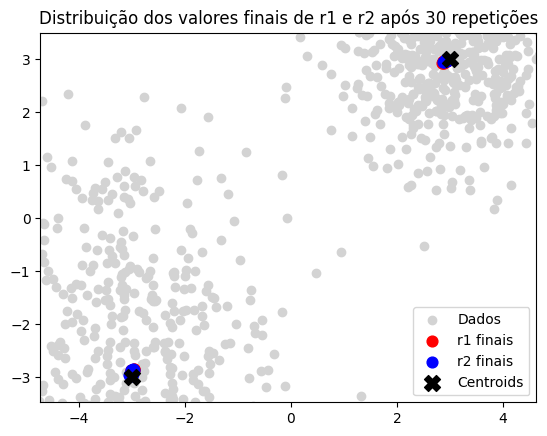

In [52]:


alpha = 0.001
num_epocas = 10
num_repeticoes = 30

r1_finais = []
r2_finais = []

for repeticao in range(1, num_repeticoes + 1):
    r1 = coordenadas[random.randint(0, len(coordenadas)-1)]
    r2 = coordenadas[random.randint(0, len(coordenadas)-1)]

    for epoca in range(num_epocas):
        for x in coordenadas:
            d1 = np.sqrt(np.sum((x-r1) ** 2))
            d2 = np.sqrt(np.sum((x-r2) ** 2))

            if d1 < d2:
                r1 = (1-alpha) * r1 + alpha * x
                
            else:
                r2 = (1-alpha) * r2 + alpha * x
        
    r1_finais.append(r1.copy())
    r2_finais.append(r2.copy())
    print(f"Repetição {repeticao:02d} - r1 final: [{r1[0]:.3f}, {r1[1]:.3f}], r2 final: [{r2[0]:.3f}, {r2[1]:.3f}]")
                
        


r1_finais = np.array(r1_finais)
r2_finais = np.array(r2_finais)

r1_media = np.mean(r1_finais, axis=0)
r2_media = np.mean(r2_finais, axis=0)
r1_std = np.std(r1_finais, axis=0)
r2_std = np.std(r2_finais, axis=0)

print("\n--- Estatísticas dos resultados ---")
print(f"Média r1: [{r1_media[0]}, {r1_media[1]}] | Desvio padrão: [{r1_std[0]}, {r1_std[1]}]")
print(f"Média r2: [{r2_media[0]}, {r2_media[1]}] | Desvio padrão: [{r2_std[0]}, {r2_std[1]}]")



plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='o', label='Dados')
plt.scatter(r1_finais[:,0], r1_finais[:,1], c='red', s=60, marker='o', label='r1 finais')
plt.scatter(r2_finais[:,0], r2_finais[:,1], c='blue', s=60, marker='o', label='r2 finais')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.title("Distribuição dos valores finais de r1 e r2 após 30 repetições")
plt.legend()
plt.axis('equal')
plt.show()

plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='o', label='Dados')
plt.scatter(r1_finais[:,0], r1_finais[:,1], c='red', s=60, marker='o', label='r1 finais')
plt.scatter(r2_finais[:,0], r2_finais[:,1], c='blue', s=60, marker='o', label='r2 finais')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.title("Distribuição dos valores finais de r1 e r2 após 30 repetições")
plt.legend()
plt.axis('equal')
todos = np.vstack((r1_finais, r2_finais))
plt.xlim(todos[:,0].min()-0.5, todos[:,0].max()+0.5)
plt.ylim(todos[:,1].min()-0.5, todos[:,1].max()+0.5)
plt.show()

**Kmeans - pontos acumulados**

Época 0 - r1: [-2.301;-6.554], r2: [2.788;3.258]
Época 1 - r1: [-2.3730236494906447;-6.226757349723275], r2: [2.752752767577076;3.210621504030404]
Época 2 - r1: [-2.439226721216893;-5.925453507193312], r2: [2.7301741068686916;3.1712711956075768]
Época 3 - r1: [-2.4987915361521864;-5.647366735519289], r2: [2.7191604235713935;3.1400465365848302]
Época 4 - r1: [-2.552431334305562;-5.394692100510948], r2: [2.712445312757369;3.113270018728358]
Época 5 - r1: [-2.6002424687897276;-5.1635212051555195], r2: [2.7113604879236757;3.091524491724246]
Época 6 - r1: [-2.643223244068401;-4.951352286834557], r2: [2.7158099391674755;3.073956257041278]
Época 7 - r1: [-2.6820418249783144;-4.75856271692978], r2: [2.72215305554639;3.058779800923556]
Época 8 - r1: [-2.717166549782183;-4.584016011065962], r2: [2.729146588021901;3.0453421471944804]
Época 9 - r1: [-2.7483610500364626;-4.424488192417772], r2: [2.738425343395582;3.0344491818822523]
Época 10 - r1: [-2.7767261948832727;-4.27790909364008], r2: [2.750

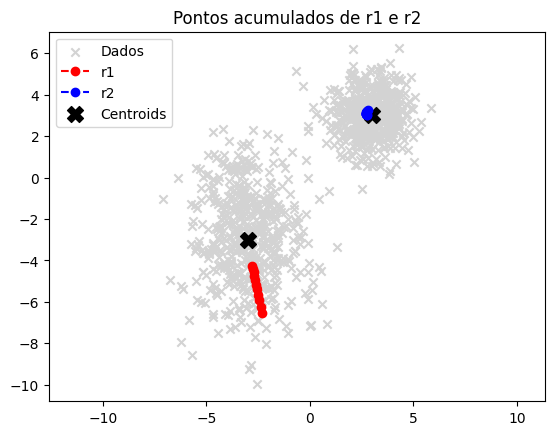

In [55]:


r1 = coordenadas[random.randint(0 , len(coordenadas)-1)]
r2 = coordenadas[random.randint(0 , len(coordenadas)-1)]

alpha = 0.1
num_epocas = 10


r1_acc = []
r2_acc = []

r1_acc.append(r1.copy())
r2_acc.append(r2.copy())
print(f"Época 0 - r1: [{r1[0]};{r1[1]}], r2: [{r2[0]};{r2[1]}]")

for epoca in range(1, num_epocas + 1):
    d1_total = np.zeros(2)
    d2_total = np.zeros(2)
    n1 = 0
    n2 = 0
    for x in coordenadas:
        d1 = np.sqrt(np.sum((x-r1) ** 2))
        d2 = np.sqrt(np.sum((x-r2) ** 2))

        if d1 < d2:
            d1_total += (x - r1)
            n1 += 1
        else:
            d2_total += (x - r2)
            n2 += 1

    if n1 > 0:
        r1 += alpha * (d1_total / n1)
    if n2 > 0:
        r2 += alpha * (d2_total / n2)       
    
    r1_acc.append(r1.copy())
    r2_acc.append(r2.copy())
    print(f"Época {epoca} - r1: [{r1[0]};{r1[1]}], r2: [{r2[0]};{r2[1]}]")


r1_acc = np.array(r1_acc)
r2_acc = np.array(r2_acc)

plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='x', label='Dados')
plt.plot(r1_acc[:,0], r1_acc[:,1], 'ro--', label='r1')
plt.plot(r2_acc[:,0], r2_acc[:,1], 'bo--', label='r2')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.title("Pontos acumulados de r1 e r2")
plt.legend()
plt.axis('equal')
plt.show()

Alínea 5

Comparando os resultados obtidos do kmeans acumulativo com o anterior efetuado, foi possível observar diferenças a nível da oscilação/movimentação dos centroids gerados, ou seja, com valores baixos de alpha (10e-5), os centroids deste tipo de kmeans movimentaram-se muito pouco comparativamente ao anterior, sendo só possível verificar a nivél visual alguma variação dos centroids para valores de alpha 10e-1. 
Em relação ao número de épocas é necessário mais épocas neste tipo de kmeans para os centroids gerados convergirem corretamente para os pontos médios de cada conjunto.

**Gráfico de cores consoante as etiquetas e a proximidade aos pontos r1 e r2**

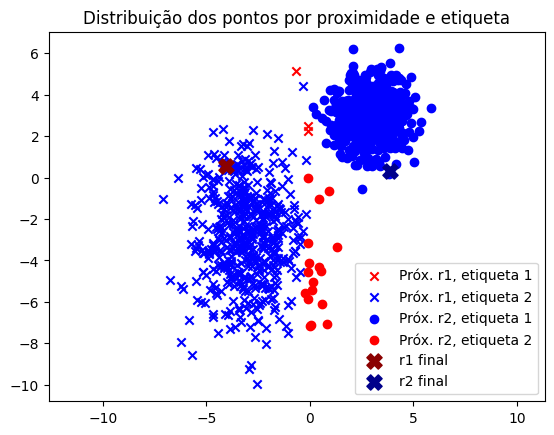

In [62]:

r1 = coordenadas[random.randint(0, len(coordenadas)-1)]
r2 = coordenadas[random.randint(0, len(coordenadas)-1)]

dist_r1 = np.sqrt(np.sum((coordenadas-r1) ** 2, axis=1))
dist_r2 = np.sqrt(np.sum((coordenadas-r2) ** 2, axis=1))
prox_r1 = dist_r1 < dist_r2  


r1_etiqueta1 = (prox_r1) & (etiquetas == 1)
r1_etiqueta2 = (prox_r1) & (etiquetas == 2)
r2_etiqueta1 = (~prox_r1) & (etiquetas == 1)
r2_etiqueta2 = (~prox_r1) & (etiquetas == 2)


plt.scatter(coordenadas[r1_etiqueta1,0], coordenadas[r1_etiqueta1,1], c='red', marker='x', label='Próx. r1, etiqueta 1')
plt.scatter(coordenadas[r1_etiqueta2,0], coordenadas[r1_etiqueta2,1], c='blue', marker='x', label='Próx. r1, etiqueta 2')
plt.scatter(coordenadas[r2_etiqueta1,0], coordenadas[r2_etiqueta1,1], c='blue', marker='o', label='Próx. r2, etiqueta 1')
plt.scatter(coordenadas[r2_etiqueta2,0], coordenadas[r2_etiqueta2,1], c='red', marker='o', label='Próx. r2, etiqueta 2')

plt.scatter(r1[0], r1[1], c='darkred', s=120, marker='X', label='r1 final')
plt.scatter(r2[0], r2[1], c='darkblue', s=120, marker='X', label='r2 final')

plt.title("Distribuição dos pontos por proximidade e etiqueta")
plt.legend()
plt.axis('equal')
plt.show()

Alínea 6

Com a analise do grafico acima, e comparando com o grafico efetuado inicialmente onde foi feito a divisão dos conjuntos por etiquetas (juntamente com a visualização das cores de cada etiqueta), foi possível perceber que quando é gerado dois centroids (r1 e r2), a identificação das etiquetas dos pontos mais próximos tem alguns erros, nomeadamente na taxa de acerto, ou seja é possível verificar pontos com etiqueta errada.

**Experiência de 30 tentativas**

Repetição 01 - r1 final: [3.297, 3.647], r2 final: [-0.255, -0.688]
Repetição 02 - r1 final: [3.306, 2.647], r2 final: [-2.653, -3.619]
Repetição 03 - r1 final: [-2.575, -3.045], r2 final: [3.092, 2.331]
Repetição 04 - r1 final: [-3.146, -5.000], r2 final: [-0.188, 0.058]
Repetição 05 - r1 final: [3.515, 2.401], r2 final: [-2.337, -2.718]
Repetição 06 - r1 final: [3.008, 2.643], r2 final: [-2.990, -3.252]
Repetição 07 - r1 final: [-3.271, -3.308], r2 final: [1.549, 0.965]
Repetição 08 - r1 final: [3.321, 3.907], r2 final: [0.139, -0.091]
Repetição 09 - r1 final: [2.653, 3.411], r2 final: [-0.955, -0.967]
Repetição 10 - r1 final: [0.627, 0.837], r2 final: [3.268, 4.762]
Repetição 11 - r1 final: [3.664, 1.982], r2 final: [-0.247, -0.146]
Repetição 12 - r1 final: [-3.057, -5.472], r2 final: [0.327, -0.694]
Repetição 13 - r1 final: [3.227, 2.976], r2 final: [-3.039, -2.939]
Repetição 14 - r1 final: [0.719, 2.031], r2 final: [-3.024, -3.393]
Repetição 15 - r1 final: [-0.665, -1.515], r2 fin

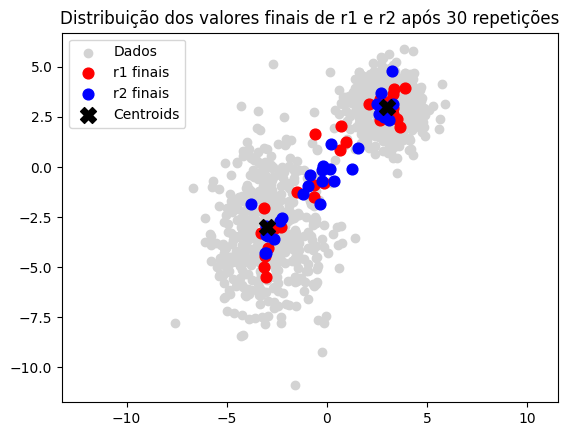

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


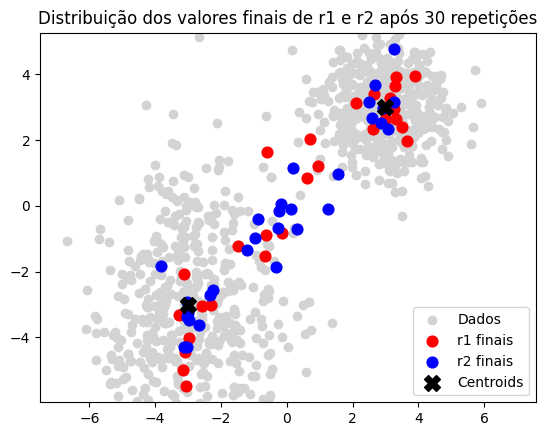

In [ ]:

alpha = 0.1
num_epocas = 10
num_repeticoes = 30

r1_finais = []
r2_finais = []

for repeticao in range(1, num_repeticoes + 1):
    r1 = coordenadas[random.randint(0, len(coordenadas)-1)]
    r2 = coordenadas[random.randint(0, len(coordenadas)-1)]

    for epoca in range(num_epocas):
        d1_total = np.zeros(2)
        d2_total = np.zeros(2)
        n1 = 0
        n2 = 0

        for x in coordenadas:
            d1 = np.sqrt(np.sum((x - r1) ** 2))
            d2 = np.sqrt(np.sum((x - r2) ** 2))

            if d1 < d2:
                d1_total += (x - r1)
                n1 += 1
            else:
                d2_total += (x - r2)
                n2 += 1

        if n1 > 0:
            r1 += alpha * (d1_total / n1)
        if n2 > 0:
            r2 += alpha * (d2_total / n2)

    r1_finais.append(r1.copy())
    r2_finais.append(r2.copy())

    print(f"Repetição {repeticao:02d} - r1 final: [{r1[0]:.3f}, {r1[1]:.3f}], r2 final: [{r2[0]:.3f}, {r2[1]:.3f}]")


r1_finais = np.array(r1_finais)
r2_finais = np.array(r2_finais)

print("\n--- Estatísticas dos resultados ---")
print(f"Média r1: [{r1_media[0]}, {r1_media[1]}] | Desvio padrão: [{r1_std[0]}, {r1_std[1]}]")
print(f"Média r2: [{r2_media[0]}, {r2_media[1]}] | Desvio padrão: [{r2_std[0]}, {r2_std[1]}]")


plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='o', label='Dados')
plt.scatter(r1_finais[:,0], r1_finais[:,1], c='red', s=60, marker='o', label='r1 finais')
plt.scatter(r2_finais[:,0], r2_finais[:,1], c='blue', s=60, marker='o', label='r2 finais')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.title("Distribuição dos valores finais de r1 e r2 após 30 repetições")
plt.legend()
plt.axis('equal')
plt.show()

plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='o', label='Dados')
plt.scatter(r1_finais[:,0], r1_finais[:,1], c='red', s=60, marker='o', label='r1 finais')
plt.scatter(r2_finais[:,0], r2_finais[:,1], c='blue', s=60, marker='o', label='r2 finais')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.title("Distribuição dos valores finais de r1 e r2 após 30 repetições")
plt.legend()
plt.axis('equal')
todos = np.vstack((r1_finais, r2_finais))
plt.xlim(todos[:,0].min()-0.5, todos[:,0].max()+0.5)
plt.ylim(todos[:,1].min()-0.5, todos[:,1].max()+0.5)
plt.show()

**Exercicio 2 - Clustering aglomerativo hierárquico**

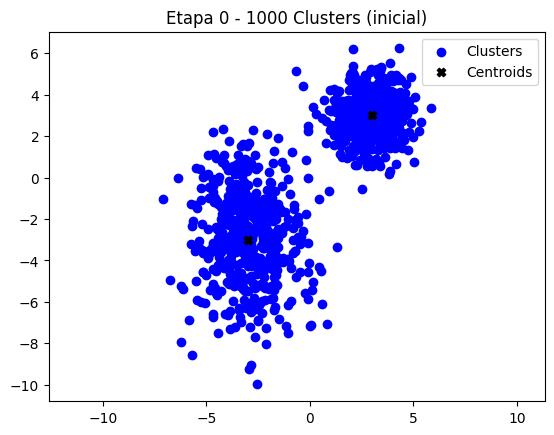

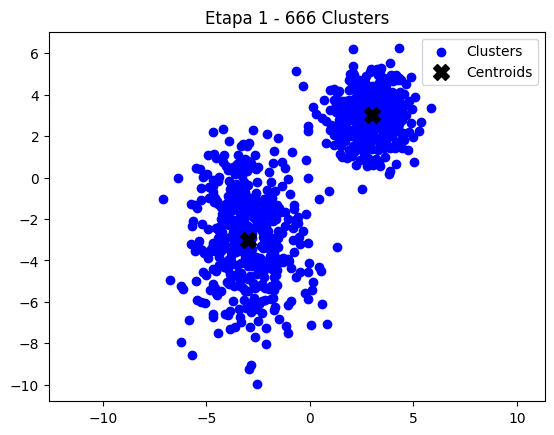

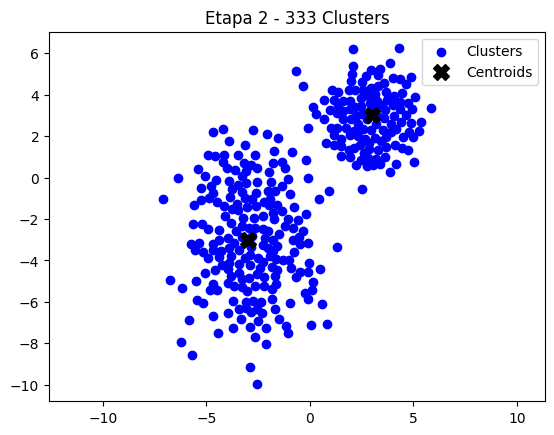

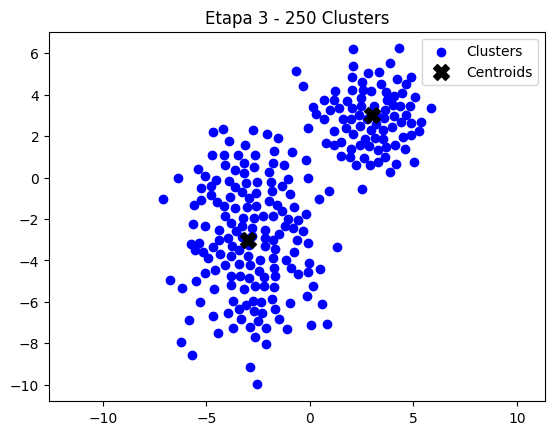

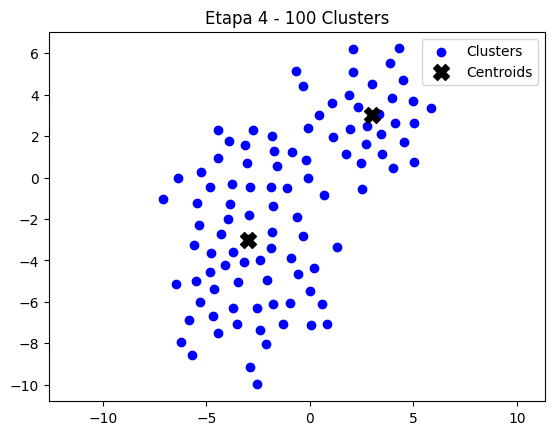

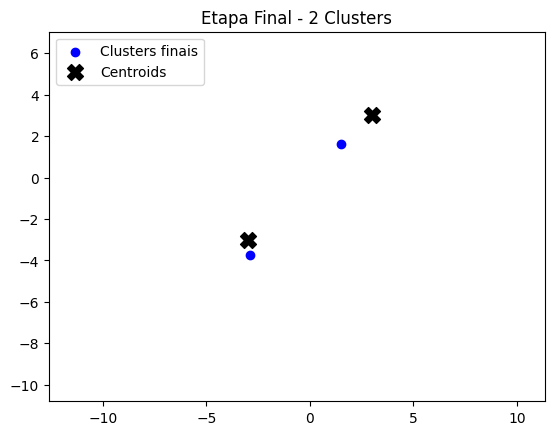

In [68]:
pontos = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
pontos_iniciais = pontos.copy() 
n_inicial = len(pontos)


marcos = [int(2*n_inicial/3), int(n_inicial/3), 250, 100]



plt.scatter(pontos[:,0], pontos[:,1], c='blue', label='Clusters')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', label='Centroids')
plt.axis('equal')
plt.title(f"Etapa 0 - {n_inicial} Clusters (inicial)")
plt.legend()
plt.show()


while len(pontos) > 2:
    min_dist = float('inf')
    p1, p2 = None, None
    for i in range(len(pontos)):
        for j in range(i+1, len(pontos)):
            d = np.sqrt(np.sum((pontos[i]-pontos[j])**2))
            if d < min_dist:
                min_dist = d
                p1, p2 = i, j

    novo_ponto = (pontos[p1] + pontos[p2])/2
    pontos = np.delete(pontos, [p1,p2], axis=0)
    pontos = np.vstack([pontos, novo_ponto])

    if len(pontos) in marcos:
        idx = marcos.index(len(pontos))
        plt.scatter(pontos[:,0], pontos[:,1], c='blue', label='Clusters')
        plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
        plt.axis('equal')
        plt.title(f"Etapa {idx+1} - {len(pontos)} Clusters")
        plt.legend()
        plt.show()


plt.scatter(pontos_iniciais[:,0], pontos_iniciais[:,1], c='white', alpha=0)
plt.scatter(pontos[:,0], pontos[:,1], c='blue', label='Clusters finais')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.axis('equal')
plt.title("Etapa Final - 2 Clusters")
plt.legend()
plt.show()

**Exercicio 3 - Algoritmo DBSCAN** 

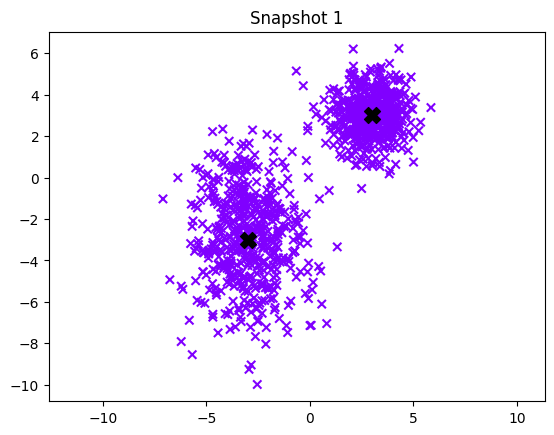

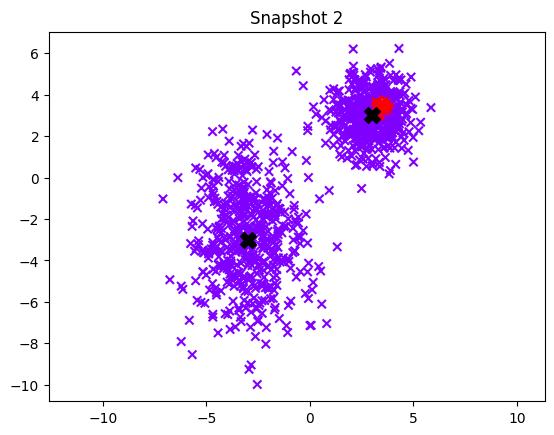

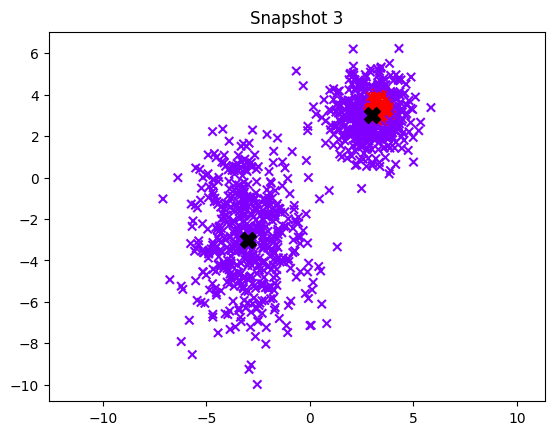

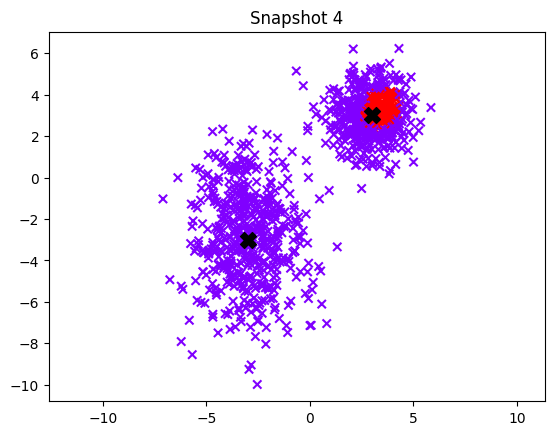

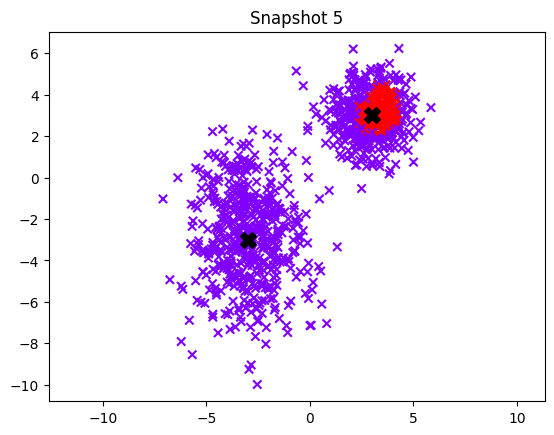

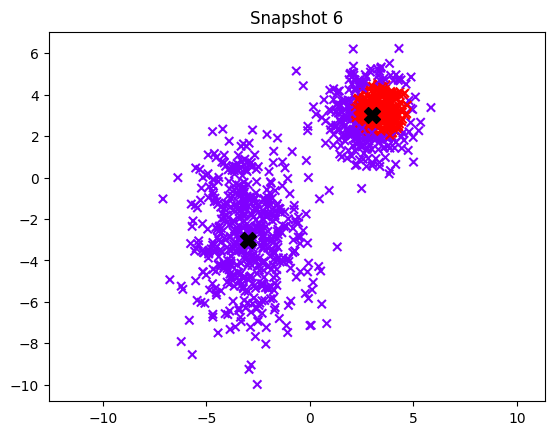

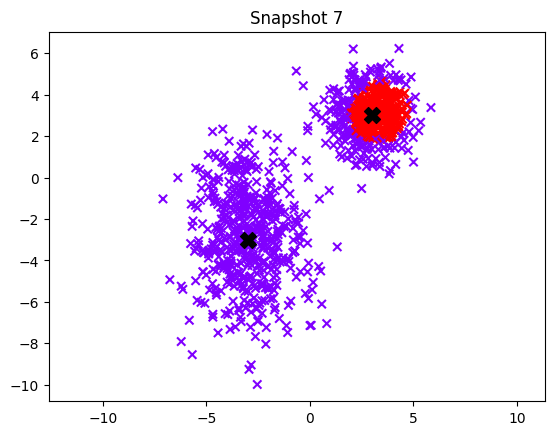

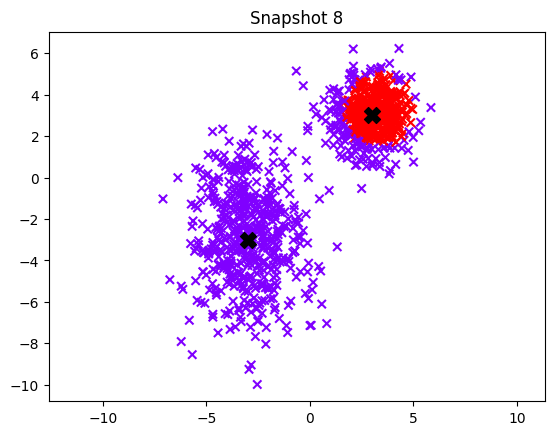

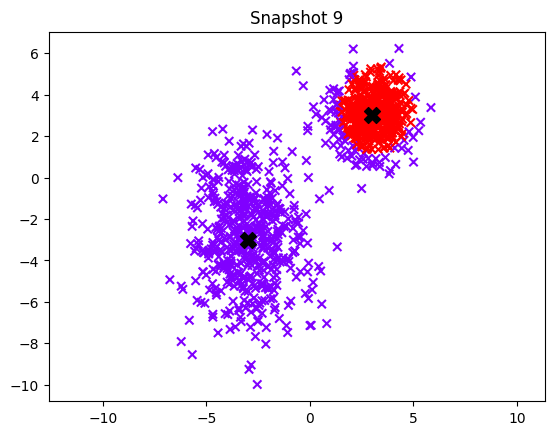

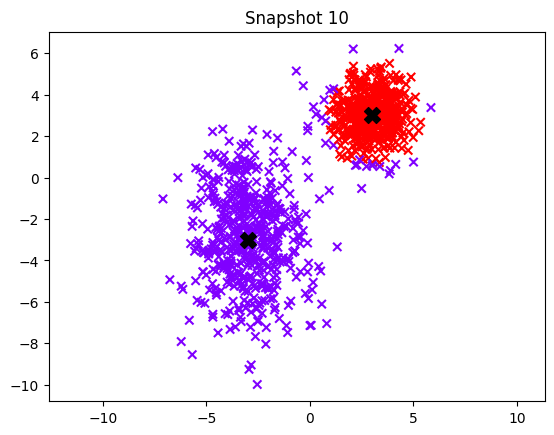

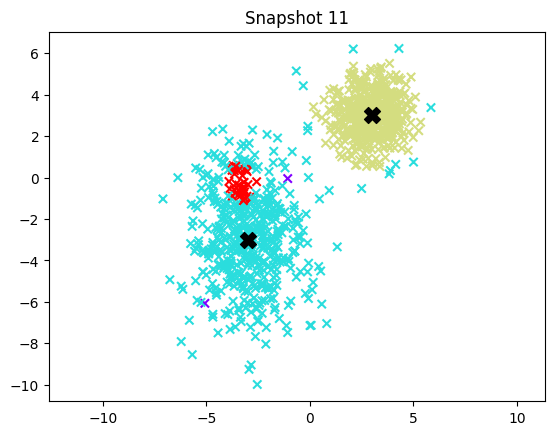

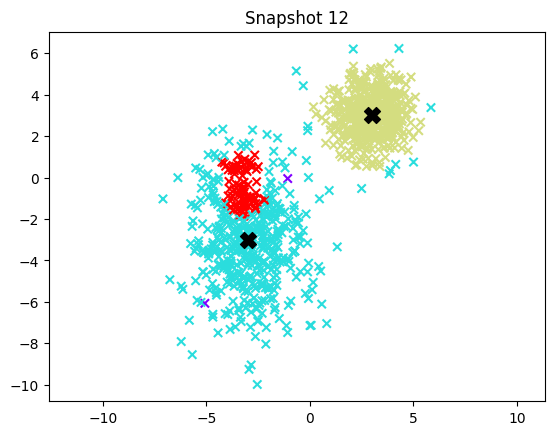

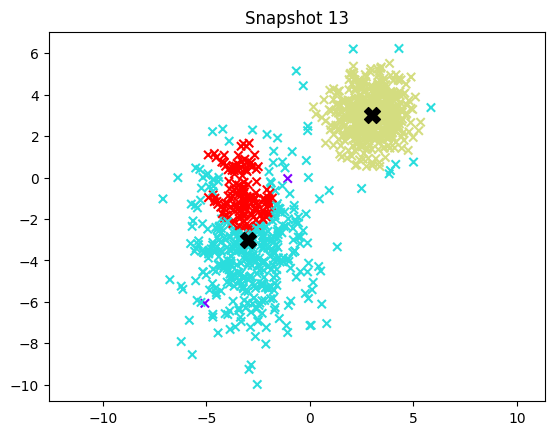

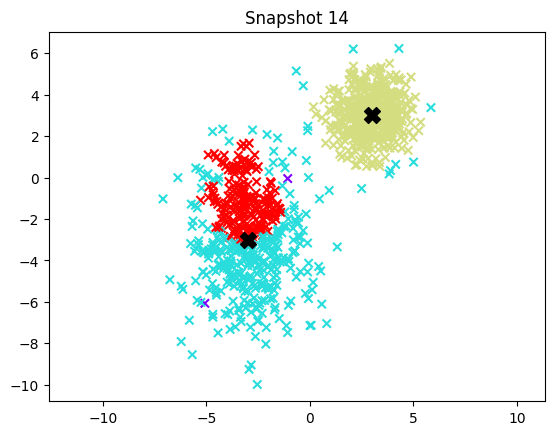

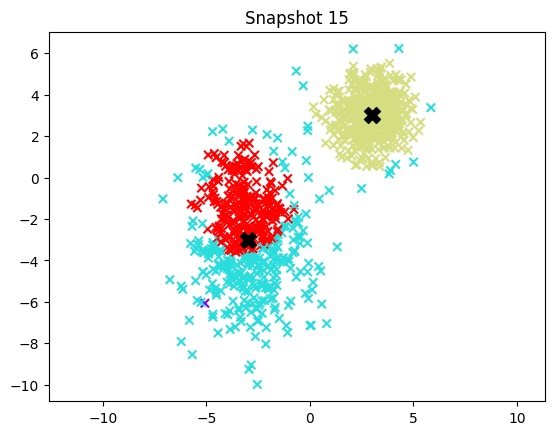

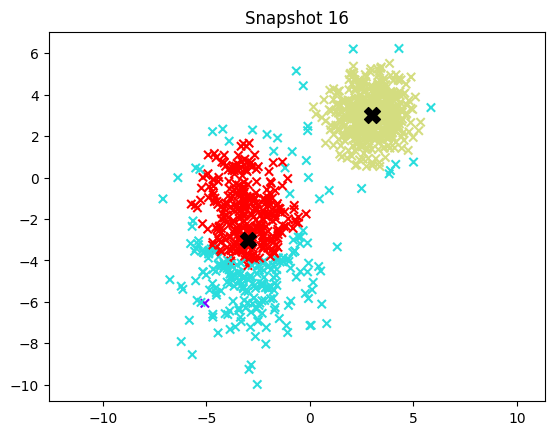

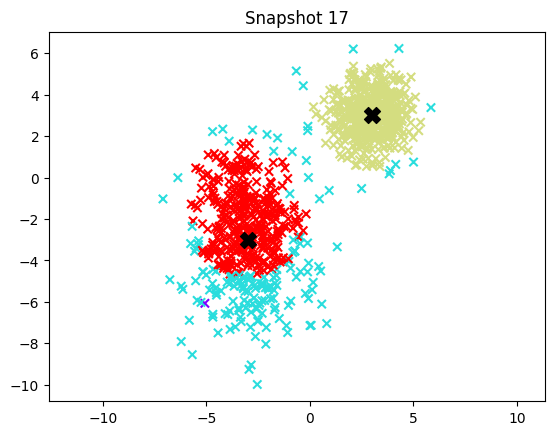

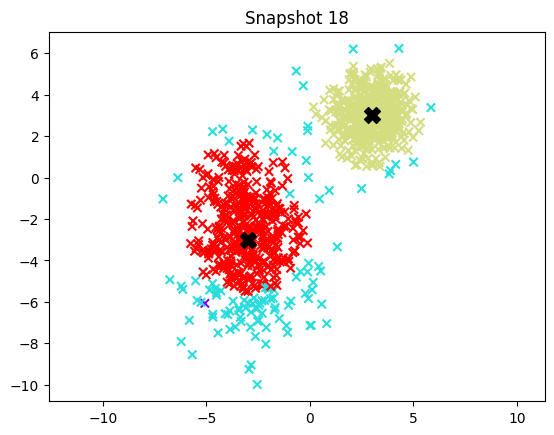

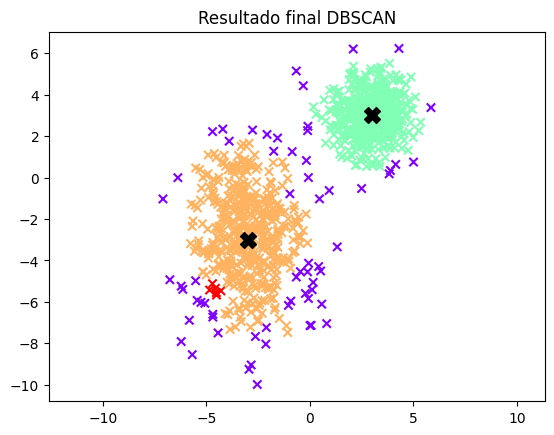

In [75]:
data = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
n_points = len(data)

eps = 0.5
min_samples = 5
labels = np.zeros(n_points, dtype=int)  
cluster_id = 1

num_snapshots = 20
snapshot_indices = np.linspace(0, n_points-1, num_snapshots, dtype=int)
snapshots = []
step_counter = 0 



for i in range(n_points):
    if labels[i] != 0:
        continue

    neighbors = []
    for j in range(n_points):
        if np.sqrt(np.sum((data[i] - data[j]) ** 2)) <= eps:
            neighbors.append(j)

    if len(neighbors) < min_samples:
        labels[i] = -1  
    else:
        labels[i] = cluster_id
        k = 0
        while k < len(neighbors):
            idx = neighbors[k]
            if labels[idx] == -1:
                labels[idx] = cluster_id
            elif labels[idx] == 0:
                labels[idx] = cluster_id
                for j in range(n_points):
                    if np.sqrt(np.sum((data[idx] - data[j]) ** 2)) <= eps and j not in neighbors:
                        neighbors.append(j)

            k += 1
            step_counter += 1

            
            while snapshot_indices.size > 0 and step_counter >= snapshot_indices[0]:
                snapshots.append(labels.copy())
                snapshot_indices = snapshot_indices[1:]  
                if len(snapshots) >= num_snapshots:
                    break

        cluster_id += 1

    if len(snapshots) >= num_snapshots:
        break  


for i, snapshot_labels in enumerate(snapshots):
    plt.scatter(data[:, 0], data[:, 1], c=snapshot_labels, cmap='rainbow', marker='x')
    plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
    plt.axis('equal')
    plt.title(f"Snapshot {i + 1}")
    plt.show()


plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='rainbow', marker='x')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s = 130, label='Centroids')
plt.axis('equal')
plt.title("Resultado final DBSCAN")
plt.show()